In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.Descriptors import MolLogP
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem import Descriptors
from rdkit.Chem import PandasTools
from rdkit.DataStructs import ExplicitBitVect

import sys
import multiprocessing
from standardiser import break_bonds, neutralise, rules, unsalt
from standardiser.utils import StandardiseException, sanity_check
def warn(*args, **kwargs):
    pass 
import warnings
warnings.filterwarnings("ignore")
warnings.warn = warn
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import sys
from sklearn.metrics import cohen_kappa_score
import csv
from rdkit.Chem import MACCSkeys
from sklearn.model_selection import ShuffleSplit
import _pickle as cPickle
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit    
import bz2
from glob import glob
import _pickle as cPickle
import pickle





In [2]:
# Function to read SDF file into DataFrame
def load_sdf_to_df(filename):
    suppl = Chem.SDMolSupplier(filename)
    rows = []
    for mol in suppl:
        if mol is not None:
            row = {prop: mol.GetProp(prop) for prop in mol.GetPropNames()}
            row['SMILES'] = Chem.MolToSmiles(mol)
            rows.append(row)
    return pd.DataFrame(rows)

# Load the  test sets from SDF files
test_df = load_sdf_to_df(r'C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Respiratory Irritation\dataset\test_set_respiratory_irritatio_features_rdkitcdk.sdf')

# Convert strings back to lists of integers
def string_to_list(bit_string):
    if isinstance(bit_string, str):
        return list(map(int, bit_string.strip('[]').split(', ')))
    else:
        return bit_string


test_df['Morgan_Descriptors'] = test_df['Morgan_Descriptors'].apply(string_to_list)
test_df['MACCS_Descriptors'] = test_df['MACCS_Descriptors'].apply(string_to_list)

def string_to_list(descriptor):
    if isinstance(descriptor, str):
        return list(map(float, descriptor.strip('[]').split(',')))
    return descriptor

# Apply the function to the 'Modred_Descriptor' column
test_df['Modred_Descriptor'] = test_df['Modred_Descriptor'].apply(string_to_list)

# Convert 'Modred_Descriptor' column to a NumPy array
data_modred_test = np.array(test_df['Modred_Descriptor'].tolist())


print("Test DataFrame:")
print(test_df.head())


[17:21:13] WARNING: not removing hydrogen atom without neighbors
[17:21:13] WARNING: not removing hydrogen atom without neighbors


Test DataFrame:
                                                name Outcome    ID RowID  \
0                                N-methylmethanamine       1   568   568   
1       dimethoxy-(2-methylpropyl)-propan-2-ylsilane       1  1653  1653   
2                  cerium(4+);disulfate;tetrahydrate       1  1343  1343   
3  4,5,6,7-tetrachloro-3-[4-[(4,5,6,7-tetrachloro...       0  3312  3312   
4                     2-ethylhexyl carbonochloridate       1  1466  1466   

                                  Morgan_Descriptors  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
2  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
3  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
4  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   MACCS_Descriptors  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
2  [0, 0, 0, 0, 0, 0, 

In [3]:
test_df

,name,Outcome,ID,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,SMILES,Molecular Weight,logP,...,nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3
0,N-methylmethanamine,1,568,568,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.7838422003386987, -0.7103490381116897, -0....",CNC,45.057849223999995,-0.1644000000000001,...,1.0,0.0,3.0,0.5,0.0,0.0,12.03,2.0,-0.176,1.0
1,dimethoxy-(2-methylpropyl)-propan-2-ylsilane,1,1653,1653,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.4641784768228143, -0.5779053735880487, -0....",CO[Si](CC(C)C)(OC)C(C)C,190.138906474,2.7874000000000008,...,0.0,3.0,6.0,0.4,5.0,0.0,18.46,4.459431618637298,2.828,1.0
2,cerium(4+);disulfate;tetrahydrate,1,1343,1343,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.720757043809812, -0.5908509949324647, 0.631...",O.O.O.O.O=S(=O)([O-])[O-].O=S(=O)([O-])[O-].[C...,403.85115639599996,-5.974799999999997,...,4.0,0.0,3.0,0.999000000999,0.0,1.0,177.28,4.0,-5.396000000000001,0.0
3,"4,5,6,7-tetrachloro-3-[4-[(4,5,6,7-tetrachloro...",0,3312,3312,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.0239046482374619, 1.6686578381813821, 1.407...",O=C1NC(=Nc2ccc(N=C3NC(=O)c4c(Cl)c(Cl)c(Cl)c(Cl...,637.7998968720002,8.557199999999998,...,2.0,0.0,0.0,0.4705882352941176,2.0,2.0,82.91999999999999,6.321928094887363,8.254000000000001,0.0
4,2-ethylhexyl carbonochloridate,1,1466,1466,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.3887036535475109, -0.3289511169646631, -0....",CCCCC(CC)COC(=O)Cl,192.091707464,3.5782000000000025,...,0.0,7.0,9.0,0.5,7.0,0.0,26.3,4.459431618637298,3.991000000000001,0.8888888888888888
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
729,ethoxyethane;trifluoroborane,1,417,417,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.06827173844612727, -0.3384113787163518, -0...",CCOCC.FB(F)F,142.07768,1.9226,...,0.0,2.0,5.0,0.999000000999,2.0,0.0,9.23,3.807354922057604,2.402,1.0
730,"11-methoxy-6,8,16,20-tetraoxapentacyclo[10.8.0...",1,877,877,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.896192797148208, 1.2389627912494188, 1.2104...",COc1cc2c(c3oc(=O)c4c(c13)CCOC4=O)C1C=COC1O2,328.058302724,1.8604999999999996,...,0.0,0.0,2.0,0.4444444444444444,1.0,0.0,84.20000000000002,5.807354922057604,2.451,0.2941176470588235
731,2-ethoxy-N'-hydroxybenzenecarboximidamide,0,2095,2095,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.13827319667474838, 0.051450987155869904, -...",CCOc1ccccc1C(N)=NO,180.089877624,1.1798,...,2.0,2.0,4.0,0.4285714285714285,3.0,0.0,67.84,4.700439718141093,1.807,0.2222222222222222
732,"4,5-dichloro-2-octyl-1,2-thiazol-3-one",1,1585,1585,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.3107322076193348, -0.18953673325556725, -0...",CCCCCCCCn1sc(Cl)c(Cl)c1=O,281.040790524,4.577100000000004,...,0.0,8.0,8.0,0.4545454545454545,7.0,0.0,50.24,5.0,4.927,0.7272727272727273


In [4]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Create the label encoder
le = LabelEncoder()

# Get unique outcomes
outcomes = np.unique(test_df['Outcome'])
le.fit(list(set(outcomes)))

# Transform the 'Outcome' column
y = le.transform(test_df['Outcome'])

# Print class information
print("Classes                          : ", outcomes)
print("Number of cpds in each class     : ", [len(y[y == smi]) for smi in np.unique(y)])
print("Total number of cpds             : ", len(y))

# Explicitly map the outcome classes
S = test_df['Outcome']

# Ensure the class mapping is applied explicitly and consistently
info = {0: 0, 1: 1}  # Ensure '0' is mapped to 0 and '1' is mapped to 1
S = S.replace(info)

# Print the class replacement info for reference
print("Class mapping: ", info)


Classes                          :  ['0' '1']
Number of cpds in each class     :  [394, 340]
Total number of cpds             :  734
Class mapping:  {0: 0, 1: 1}


0    394
1    340
Name: Outcome, dtype: int64


{0: 0, 1: 1}

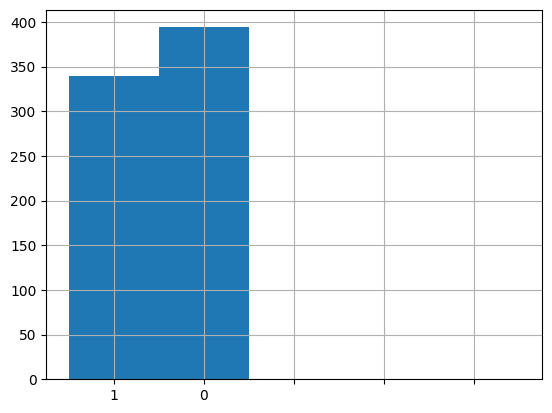

In [5]:
#checking the test df value data
print(test_df['Outcome'].value_counts())

#graph
ax = S.hist(bins=np.arange(-0.5,5))
ax.set_xticks(range(0,5))
info

In [6]:
# AFTER
import joblib

base_path = r"C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Respiratory Irritation\model\fingerprint descriptor model"

rf_morgan = joblib.load(fr"{base_path}\Model_Respiratory_RF_morgan.pkl")  
rf_maccs = joblib.load(fr"{base_path}\Model_Respiratory_RF_maccskey.pkl")
rf_modred = joblib.load(fr"{base_path}\Model_Respiratory_RF_modred.pkl")

svm_morgan = joblib.load(fr"{base_path}\Model_Respiratory_SVM_morgan.pkl")  
svm_maccs = joblib.load(fr"{base_path}\Model_Respiratory_SVM_maccskey.pkl")
svm_modred = joblib.load(fr"{base_path}\Model_Respiratory_SVM_modred.pkl")

xgb_morgan = joblib.load(fr"{base_path}\Model_Respiratory_XGB_morgan.pkl")  
xgb_maccs = joblib.load(fr"{base_path}\Model_Respiratory_XGB_maccskey.pkl")
xgb_modred = joblib.load(fr"{base_path}\Model_Respiratory_XGB_modred.pkl")

nn_morgan = joblib.load(fr"{base_path}\Model_Respiratory_NN_morgan.pkl")  
nn_maccs = joblib.load(fr"{base_path}\Model_Respiratory_NN_maccskey.pkl")
nn_modred = joblib.load(fr"{base_path}\Model_Respiratory_NN_modred.pkl")

lgbm_morgan = joblib.load(fr"{base_path}\Model_Respiratory_LGBM_morgan.pkl")  
lgbm_maccs = joblib.load(fr"{base_path}\Model_Respiratory_LGBM_maccskey.pkl")
lgbm_modred = joblib.load(fr"{base_path}\Model_Respiratory_LGBM_modred.pkl")


In [7]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score, classification_report


In [8]:
y_true = test_df['Outcome'].astype(int)  # Ensure it's of integer type, suitable for metrics calculation


In [22]:
#RF
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

# ==============================
# Predict probabilities from RF models (Morgan, MACCS, Modred)
# ==============================
def predict_with_models_probabilities(test_df):
    # Get probabilities for each descriptor
    morgan_probs = rf_morgan.predict_proba(np.array(list(test_df['Morgan_Descriptors'].values)))[:, 1]
    maccs_probs  = rf_maccs.predict_proba(np.array(list(test_df['MACCS_Descriptors'].values)))[:, 1]
    modred_probs = rf_modred.predict_proba(np.array(list(test_df['Modred_Descriptor'].values)))[:, 1]

    # Convert probabilities to binary predictions (threshold = 0.5)
    morgan_predictions = (morgan_probs > 0.5).astype(int)
    maccs_predictions  = (maccs_probs > 0.5).astype(int)
    modred_predictions = (modred_probs > 0.5).astype(int)

    return {
        "Morgan": (morgan_predictions, morgan_probs),
        "MACCS": (maccs_predictions, maccs_probs),
        "Modred": (modred_predictions, modred_probs)
    }

# ==============================
# Evaluation function
# ==============================
def evaluate_performance(y_true, predictions, probabilities):
    conf_matrix = confusion_matrix(y_true, predictions)
    accuracy    = accuracy_score(y_true, predictions)
    auc_score   = roc_auc_score(y_true, probabilities)
    f1          = f1_score(y_true, predictions, average='binary')

    tn, fp, fn, tp = conf_matrix.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    ccr = (sensitivity + specificity) / 2
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0

    return {
        "Confusion Matrix": conf_matrix,
        "Accuracy": accuracy,
        "AUC Score": auc_score,
        "F1 Score": f1,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "CCR (Correct Classification Rate)": ccr,
        "PPV (Positive Predictive Value)": ppv,
        "NPV (Negative Predictive Value)": npv
    }

# ==============================
# Run prediction and evaluate per descriptor
# ==============================
results = predict_with_models_probabilities(test_df)

performances = {}
for desc, (preds, probs) in results.items():
    performances[desc] = evaluate_performance(y_true, preds, probs)

# Print results for each descriptor
for desc, metrics in performances.items():
    print(f"\n{desc} Performance:")
    for metric, value in metrics.items():
        print(f"{metric}: {value}")

# ==============================
# Consensus probability for RF (mean of Morgan, MACCS, Modred)
# ==============================
consensus_probs_rf = np.mean([
    results["Morgan"][1],
    results["MACCS"][1],
    results["Modred"][1]
], axis=0)

# Convert consensus probabilities to final predictions
final_predictions = (consensus_probs_rf > 0.5).astype(int)

# Evaluate RF consensus
ensemble_performance = evaluate_performance(y_true, final_predictions, consensus_probs_rf)

print("\n=== RF Consensus (Morgan + MACCS + Modred) Performance ===")
for metric, value in ensemble_performance.items():
    print(f"{metric}: {value}")



Morgan Performance:
Confusion Matrix: [[274 120]
 [103 237]]
Accuracy: 0.6961852861035422
AUC Score: 0.7543557778441325
F1 Score: 0.6800573888091822
Sensitivity: 0.6970588235294117
Specificity: 0.6954314720812182
CCR (Correct Classification Rate): 0.696245147805315
PPV (Positive Predictive Value): 0.6638655462184874
NPV (Negative Predictive Value): 0.726790450928382

MACCS Performance:
Confusion Matrix: [[286 108]
 [110 230]]
Accuracy: 0.7029972752043597
AUC Score: 0.74498730964467
F1 Score: 0.6784660766961652
Sensitivity: 0.6764705882352942
Specificity: 0.7258883248730964
CCR (Correct Classification Rate): 0.7011794565541953
PPV (Positive Predictive Value): 0.6804733727810651
NPV (Negative Predictive Value): 0.7222222222222222

Modred Performance:
Confusion Matrix: [[275 119]
 [ 91 249]]
Accuracy: 0.7138964577656676
AUC Score: 0.7560988354732756
F1 Score: 0.7033898305084746
Sensitivity: 0.7323529411764705
Specificity: 0.6979695431472082
CCR (Correct Classification Rate): 0.7151612421

In [23]:
#SVM
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

# ==============================
# Predict probabilities from SVM models (Morgan, MACCS, Modred)
# ==============================
def predict_with_models_probabilities(test_df):
    # Get probabilities for each descriptor
    morgan_probs = svm_morgan.predict_proba(np.array(list(test_df['Morgan_Descriptors'].values)))[:, 1]
    maccs_probs  = svm_maccs.predict_proba(np.array(list(test_df['MACCS_Descriptors'].values)))[:, 1]
    modred_probs = svm_modred.predict_proba(np.array(list(test_df['Modred_Descriptor'].values)))[:, 1]

    # Convert probabilities to binary predictions (threshold = 0.5)
    morgan_predictions = (morgan_probs > 0.5).astype(int)
    maccs_predictions  = (maccs_probs > 0.5).astype(int)
    modred_predictions = (modred_probs > 0.5).astype(int)

    return {
        "Morgan": (morgan_predictions, morgan_probs),
        "MACCS": (maccs_predictions, maccs_probs),
        "Modred": (modred_predictions, modred_probs)
    }

# ==============================
# Evaluation function
# ==============================
def evaluate_performance(y_true, predictions, probabilities):
    conf_matrix = confusion_matrix(y_true, predictions)
    accuracy    = accuracy_score(y_true, predictions)
    auc_score   = roc_auc_score(y_true, probabilities)
    f1          = f1_score(y_true, predictions, average='binary')

    tn, fp, fn, tp = conf_matrix.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    ccr = (sensitivity + specificity) / 2
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0

    return {
        "Confusion Matrix": conf_matrix,
        "Accuracy": accuracy,
        "AUC Score": auc_score,
        "F1 Score": f1,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "CCR (Correct Classification Rate)": ccr,
        "PPV (Positive Predictive Value)": ppv,
        "NPV (Negative Predictive Value)": npv
    }

# ==============================
# Run prediction and evaluate per descriptor
# ==============================
results = predict_with_models_probabilities(test_df)

performances = {}
for desc, (preds, probs) in results.items():
    performances[desc] = evaluate_performance(y_true, preds, probs)

# Print results for each descriptor
for desc, metrics in performances.items():
    print(f"\n{desc} Performance:")
    for metric, value in metrics.items():
        print(f"{metric}: {value}")

# ==============================
# Consensus probability for SVM (mean of Morgan, MACCS, Modred)
# ==============================
consensus_probs_svm = np.mean([
    results["Morgan"][1],
    results["MACCS"][1],
    results["Modred"][1]
], axis=0)

# Convert consensus probabilities to final predictions
final_predictions = (consensus_probs_svm > 0.5).astype(int)

# Evaluate SVM consensus
ensemble_performance = evaluate_performance(y_true, final_predictions, consensus_probs_svm)

print("\n=== SVM Consensus (Morgan + MACCS + Modred) Performance ===")
for metric, value in ensemble_performance.items():
    print(f"{metric}: {value}")



Morgan Performance:
Confusion Matrix: [[286 108]
 [111 229]]
Accuracy: 0.7016348773841962
AUC Score: 0.7485368766796058
F1 Score: 0.6765140324963073
Sensitivity: 0.6735294117647059
Specificity: 0.7258883248730964
CCR (Correct Classification Rate): 0.6997088683189012
PPV (Positive Predictive Value): 0.6795252225519288
NPV (Negative Predictive Value): 0.7204030226700252

MACCS Performance:
Confusion Matrix: [[283 111]
 [ 96 244]]
Accuracy: 0.717983651226158
AUC Score: 0.7617460435951031
F1 Score: 0.702158273381295
Sensitivity: 0.7176470588235294
Specificity: 0.7182741116751269
CCR (Correct Classification Rate): 0.7179605852493282
PPV (Positive Predictive Value): 0.6873239436619718
NPV (Negative Predictive Value): 0.7467018469656992

Modred Performance:
Confusion Matrix: [[277 117]
 [ 96 244]]
Accuracy: 0.7098092643051771
AUC Score: 0.7651388474171394
F1 Score: 0.6961483594864479
Sensitivity: 0.7176470588235294
Specificity: 0.7030456852791879
CCR (Correct Classification Rate): 0.71034637

In [24]:
#XGB
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

# ==============================
# Predict probabilities from XGB models (Morgan, MACCS, Modred)
# ==============================
def predict_with_models_probabilities(test_df):
    # Get probabilities for each descriptor
    morgan_probs = xgb_morgan.predict_proba(np.array(list(test_df['Morgan_Descriptors'].values)))[:, 1]
    maccs_probs  = xgb_maccs.predict_proba(np.array(list(test_df['MACCS_Descriptors'].values)))[:, 1]
    modred_probs = xgb_modred.predict_proba(np.array(list(test_df['Modred_Descriptor'].values)))[:, 1]

    # Convert probabilities to binary predictions (threshold = 0.5)
    morgan_predictions = (morgan_probs > 0.5).astype(int)
    maccs_predictions  = (maccs_probs > 0.5).astype(int)
    modred_predictions = (modred_probs > 0.5).astype(int)

    return {
        "Morgan": (morgan_predictions, morgan_probs),
        "MACCS": (maccs_predictions, maccs_probs),
        "Modred": (modred_predictions, modred_probs)
    }

# ==============================
# Evaluation function
# ==============================
def evaluate_performance(y_true, predictions, probabilities):
    conf_matrix = confusion_matrix(y_true, predictions)
    accuracy    = accuracy_score(y_true, predictions)
    auc_score   = roc_auc_score(y_true, probabilities)
    f1          = f1_score(y_true, predictions, average='binary')

    tn, fp, fn, tp = conf_matrix.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    ccr = (sensitivity + specificity) / 2
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0

    return {
        "Confusion Matrix": conf_matrix,
        "Accuracy": accuracy,
        "AUC Score": auc_score,
        "F1 Score": f1,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "CCR (Correct Classification Rate)": ccr,
        "PPV (Positive Predictive Value)": ppv,
        "NPV (Negative Predictive Value)": npv
    }

# ==============================
# Run prediction and evaluate per descriptor
# ==============================
results = predict_with_models_probabilities(test_df)

performances = {}
for desc, (preds, probs) in results.items():
    performances[desc] = evaluate_performance(y_true, preds, probs)

# Print results for each descriptor
for desc, metrics in performances.items():
    print(f"\n{desc} Performance:")
    for metric, value in metrics.items():
        print(f"{metric}: {value}")

# ==============================
# Consensus probability for XGB (mean of Morgan, MACCS, Modred)
# ==============================
consensus_probs_xgb = np.mean([
    results["Morgan"][1],
    results["MACCS"][1],
    results["Modred"][1]
], axis=0)

# Convert consensus probabilities to final predictions
final_predictions = (consensus_probs_xgb > 0.5).astype(int)

# Evaluate XGB consensus
ensemble_performance = evaluate_performance(y_true, final_predictions, consensus_probs_xgb)

print("\n=== XGB Consensus (Morgan + MACCS + Modred) Performance ===")
for metric, value in ensemble_performance.items():
    print(f"{metric}: {value}")



Morgan Performance:
Confusion Matrix: [[273 121]
 [109 231]]
Accuracy: 0.6866485013623979
AUC Score: 0.7460062705285161
F1 Score: 0.6676300578034682
Sensitivity: 0.6794117647058824
Specificity: 0.6928934010152284
CCR (Correct Classification Rate): 0.6861525828605555
PPV (Positive Predictive Value): 0.65625
NPV (Negative Predictive Value): 0.7146596858638743

MACCS Performance:
Confusion Matrix: [[274 120]
 [101 239]]
Accuracy: 0.6989100817438693
AUC Score: 0.7611115258286055
F1 Score: 0.6838340486409156
Sensitivity: 0.7029411764705882
Specificity: 0.6954314720812182
CCR (Correct Classification Rate): 0.6991863242759032
PPV (Positive Predictive Value): 0.6657381615598886
NPV (Negative Predictive Value): 0.7306666666666667

Modred Performance:
Confusion Matrix: [[278 116]
 [ 95 245]]
Accuracy: 0.7125340599455041
AUC Score: 0.7635861451179455
F1 Score: 0.6990014265335235
Sensitivity: 0.7205882352941176
Specificity: 0.7055837563451777
CCR (Correct Classification Rate): 0.7130859958196476


In [25]:
#NN
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

# ==============================
# Predict probabilities from NN models (Morgan, MACCS, Modred)
# ==============================
def predict_with_models_probabilities(test_df):
    # Get probabilities for each descriptor
    morgan_probs = nn_morgan.predict_proba(np.array(list(test_df['Morgan_Descriptors'].values)))[:, 1]
    maccs_probs  = nn_maccs.predict_proba(np.array(list(test_df['MACCS_Descriptors'].values)))[:, 1]
    modred_probs = nn_modred.predict_proba(np.array(list(test_df['Modred_Descriptor'].values)))[:, 1]

    # Convert probabilities to binary predictions (threshold = 0.5)
    morgan_predictions = (morgan_probs > 0.5).astype(int)
    maccs_predictions  = (maccs_probs > 0.5).astype(int)
    modred_predictions = (modred_probs > 0.5).astype(int)

    return {
        "Morgan": (morgan_predictions, morgan_probs),
        "MACCS": (maccs_predictions, maccs_probs),
        "Modred": (modred_predictions, modred_probs)
    }

# ==============================
# Evaluation function
# ==============================
def evaluate_performance(y_true, predictions, probabilities):
    conf_matrix = confusion_matrix(y_true, predictions)
    accuracy    = accuracy_score(y_true, predictions)
    auc_score   = roc_auc_score(y_true, probabilities)
    f1          = f1_score(y_true, predictions, average='binary')

    tn, fp, fn, tp = conf_matrix.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    ccr = (sensitivity + specificity) / 2
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0

    return {
        "Confusion Matrix": conf_matrix,
        "Accuracy": accuracy,
        "AUC Score": auc_score,
        "F1 Score": f1,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "CCR (Correct Classification Rate)": ccr,
        "PPV (Positive Predictive Value)": ppv,
        "NPV (Negative Predictive Value)": npv
    }

# ==============================
# Run prediction and evaluate per descriptor
# ==============================
results = predict_with_models_probabilities(test_df)

performances = {}
for desc, (preds, probs) in results.items():
    performances[desc] = evaluate_performance(y_true, preds, probs)

# Print results for each descriptor
for desc, metrics in performances.items():
    print(f"\n{desc} Performance:")
    for metric, value in metrics.items():
        print(f"{metric}: {value}")

# ==============================
# Consensus probability for NN (mean of Morgan, MACCS, Modred)
# ==============================
consensus_probs_nn = np.mean([
    results["Morgan"][1],
    results["MACCS"][1],
    results["Modred"][1]
], axis=0)

# Convert consensus probabilities to final predictions
final_predictions = (consensus_probs_nn > 0.5).astype(int)

# Evaluate NN consensus
ensemble_performance = evaluate_performance(y_true, final_predictions, consensus_probs_nn)

print("\n=== NN Consensus (Morgan + MACCS + Modred) Performance ===")
for metric, value in ensemble_performance.items():
    print(f"{metric}: {value}")



Morgan Performance:
Confusion Matrix: [[232 162]
 [116 224]]
Accuracy: 0.6212534059945504
AUC Score: 0.6819834278889221
F1 Score: 0.6170798898071626
Sensitivity: 0.6588235294117647
Specificity: 0.5888324873096447
CCR (Correct Classification Rate): 0.6238280083607046
PPV (Positive Predictive Value): 0.5803108808290155
NPV (Negative Predictive Value): 0.6666666666666666

MACCS Performance:
Confusion Matrix: [[245 149]
 [100 240]]
Accuracy: 0.6607629427792916
AUC Score: 0.7140153777246939
F1 Score: 0.6584362139917695
Sensitivity: 0.7058823529411765
Specificity: 0.6218274111675127
CCR (Correct Classification Rate): 0.6638548820543446
PPV (Positive Predictive Value): 0.6169665809768637
NPV (Negative Predictive Value): 0.7101449275362319

Modred Performance:
Confusion Matrix: [[252 142]
 [ 95 245]]
Accuracy: 0.6771117166212534
AUC Score: 0.735495670349358
F1 Score: 0.6740027510316369
Sensitivity: 0.7205882352941176
Specificity: 0.6395939086294417
CCR (Correct Classification Rate): 0.6800910

In [26]:
#LGBM
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

# ==============================
# Predict probabilities from LGBM models (Morgan, MACCS, Modred)
# ==============================
def predict_with_models_probabilities(test_df):
    # Get probabilities for each descriptor
    morgan_probs = lgbm_morgan.predict_proba(np.array(list(test_df['Morgan_Descriptors'].values)))[:, 1]
    maccs_probs  = lgbm_maccs.predict_proba(np.array(list(test_df['MACCS_Descriptors'].values)))[:, 1]
    modred_probs = lgbm_modred.predict_proba(np.array(list(test_df['Modred_Descriptor'].values)))[:, 1]

    # Convert probabilities to binary predictions (threshold = 0.5)
    morgan_predictions = (morgan_probs > 0.5).astype(int)
    maccs_predictions  = (maccs_probs > 0.5).astype(int)
    modred_predictions = (modred_probs > 0.5).astype(int)

    return {
        "Morgan": (morgan_predictions, morgan_probs),
        "MACCS": (maccs_predictions, maccs_probs),
        "Modred": (modred_predictions, modred_probs)
    }

# ==============================
# Evaluation function
# ==============================
def evaluate_performance(y_true, predictions, probabilities):
    conf_matrix = confusion_matrix(y_true, predictions)
    accuracy    = accuracy_score(y_true, predictions)
    auc_score   = roc_auc_score(y_true, probabilities)
    f1          = f1_score(y_true, predictions, average='binary')

    tn, fp, fn, tp = conf_matrix.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    ccr = (sensitivity + specificity) / 2
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0

    return {
        "Confusion Matrix": conf_matrix,
        "Accuracy": accuracy,
        "AUC Score": auc_score,
        "F1 Score": f1,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "CCR (Correct Classification Rate)": ccr,
        "PPV (Positive Predictive Value)": ppv,
        "NPV (Negative Predictive Value)": npv
    }

# ==============================
# Run prediction and evaluate per descriptor
# ==============================
results = predict_with_models_probabilities(test_df)

performances = {}
for desc, (preds, probs) in results.items():
    performances[desc] = evaluate_performance(y_true, preds, probs)

# Print results for each descriptor
for desc, metrics in performances.items():
    print(f"\n{desc} Performance:")
    for metric, value in metrics.items():
        print(f"{metric}: {value}")

# ==============================
# Consensus probability for LGBM (mean of Morgan, MACCS, Modred)
# ==============================
consensus_probs_lgbm = np.mean([
    results["Morgan"][1],
    results["MACCS"][1],
    results["Modred"][1]
], axis=0)

# Convert consensus probabilities to final predictions
final_predictions = (consensus_probs_lgbm > 0.5).astype(int)

# Evaluate LGBM consensus
ensemble_performance = evaluate_performance(y_true, final_predictions, consensus_probs_lgbm)

print("\n=== LGBM Consensus (Morgan + MACCS + Modred) Performance ===")
for metric, value in ensemble_performance.items():
    print(f"{metric}: {value}")



Morgan Performance:
Confusion Matrix: [[268 126]
 [122 218]]
Accuracy: 0.662125340599455
AUC Score: 0.7249066885637504
F1 Score: 0.6374269005847953
Sensitivity: 0.6411764705882353
Specificity: 0.6802030456852792
CCR (Correct Classification Rate): 0.6606897581367572
PPV (Positive Predictive Value): 0.6337209302325582
NPV (Negative Predictive Value): 0.6871794871794872

MACCS Performance:
Confusion Matrix: [[263 131]
 [ 96 244]]
Accuracy: 0.6907356948228883
AUC Score: 0.7509853687667961
F1 Score: 0.6825174825174826
Sensitivity: 0.7176470588235294
Specificity: 0.6675126903553299
CCR (Correct Classification Rate): 0.6925798745894296
PPV (Positive Predictive Value): 0.6506666666666666
NPV (Negative Predictive Value): 0.7325905292479109

Modred Performance:
Confusion Matrix: [[268 126]
 [ 88 252]]
Accuracy: 0.7084468664850136
AUC Score: 0.7636682591818452
F1 Score: 0.7019498607242339
Sensitivity: 0.7411764705882353
Specificity: 0.6802030456852792
CCR (Correct Classification Rate): 0.7106897

In [27]:
# CONSENSUS ALL (RF + SVM + XGB + NN + LGBM)
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# ==============================
# Evaluation Function
# ==============================
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# ==============================
# STACK ALL MODEL CONSENSUS
# ==============================
all_model_probs = np.vstack([
    consensus_probs_rf,
    consensus_probs_svm,
    consensus_probs_xgb,
    consensus_probs_nn,
    consensus_probs_lgbm
])

# FINAL CONSENSUS (MEAN)
consensus_all_probs = all_model_probs.mean(axis=0)

# EVALUATION
consensus_all_metrics = evaluate_model(y_true, consensus_all_probs)

print("CONSENSUS DESKRIPTOR (RF + SVM + XGB + NN + LGBM)")
for k, v in consensus_all_metrics.items():
    print(f"{k}: {v}")


CONSENSUS DESKRIPTOR (RF + SVM + XGB + NN + LGBM)
Confusion Matrix: [[277 117]
 [ 92 248]]
Accuracy: 0.715258855585831
AUC: 0.7776873693639893
F1 Score: 0.7035460992907802
Sensitivity (Recall+): 0.7294117647058823
Specificity (Recall-): 0.7030456852791879
CCR: 0.7162287249925351
PPV (Precision): 0.6794520547945205
NPV: 0.7506775067750677
